In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from metpy.calc import wind_speed, wind_direction
from metpy.units import units

from ICONProcessor import ICONDataGrid

project_dir = '/work/bb1461/'

In [2]:
def calc_wind(u,v):
    wspd = wind_speed(u * units("m/s"), v * units("m/s"))
    wdir = wind_direction(u * units("m/s"), v * units("m/s"))
    return wspd, wdir

## Script settings

In [ ]:
# scope ='H2'
scope ='H3'

In [ ]:

# do scope specific settings
if scope == 'H2':
    scope_name = 'HEFEX II'

    cell_id = 35714


    dt_from,dt_to = '2023-08-17', '2023-09-10'

    d = project_dir + 'cdo_scripts/output_hefex2/'


    shading = [['2023-08-20 00:00','2023-08-25 00:00'],
               ['2023-08-29 00:00','2023-08-30 00:00'],
               ['2023-09-04 00:00','2023-09-07 00:00']]
    shading_c = ['#d1ced0','#b5ded5','#d4ddf2']
elif scope == 'H3':
    scope_name = 'HEFEX III'

    cell_id = 35704


    d = project_dir + 'cdo_scripts/output_hefex3/'

    dt_from,dt_to = '2025-08-06', '2025-09-01'


    shading = [['2025-08-07 00:00','2025-08-10 12:00'],
               ['2025-08-10 00:00','2025-08-11 00:00']]
    shading_c = ['#d1ced0','#b5ded5']
else:
    print('Unknown scope!')

## Get ICON data

In [4]:
ds_l5      = xr.open_dataset(d + 'v370_2030_LES_51m_ml__lowest5.nc')
ds_sfc     = xr.open_dataset(d + 'v370_2030_LES_51m_ml__sfc.nc')
ds_avg_sfc = xr.open_dataset(d + 'v370_2030_LES_30min_51m_ml__sfc.nc')
ds_pl      = xr.open_dataset(d + 'v370_2030_LES_51m_pl__uv.nc')

In [5]:
t_ml  = [ICONDataGrid.convert_float_dt(f) for f in ds_l5.time.values]
t_avg = [ICONDataGrid.convert_float_dt(f) for f in ds_avg_sfc.time.values]
t_pl  = [ICONDataGrid.convert_float_dt(f) for f in ds_pl.time.values]

In [9]:
# cloud cover (at 500hPa over tower location)
ds_cc = xr.open_dataset(d + f'v370_2030_LES_51m_pl_{cell_id}.nc')
cc = ds_cc['clc'].values[:,0,0]

# surface pressure (tower location)
ds_p = xr.open_dataset(d + f'v370_2030_LES_51m_ml_{cell_id}.nc')
pres = ds_p['pres'].values[:,-1,0] / 100

## Create plot

In [10]:
cell_idx = cell_id - 1

# sfc
wspd_sfc, wdir_sfc = calc_wind(ds_sfc['u_10m'].values[:,-1,cell_idx], ds_sfc['v_10m'].values[:,-1,cell_idx])

# 500hPa
wspd_500, wdir_500 = calc_wind(ds_pl['u'].values[:,0,cell_idx], ds_pl['v'].values[:,0,cell_idx])

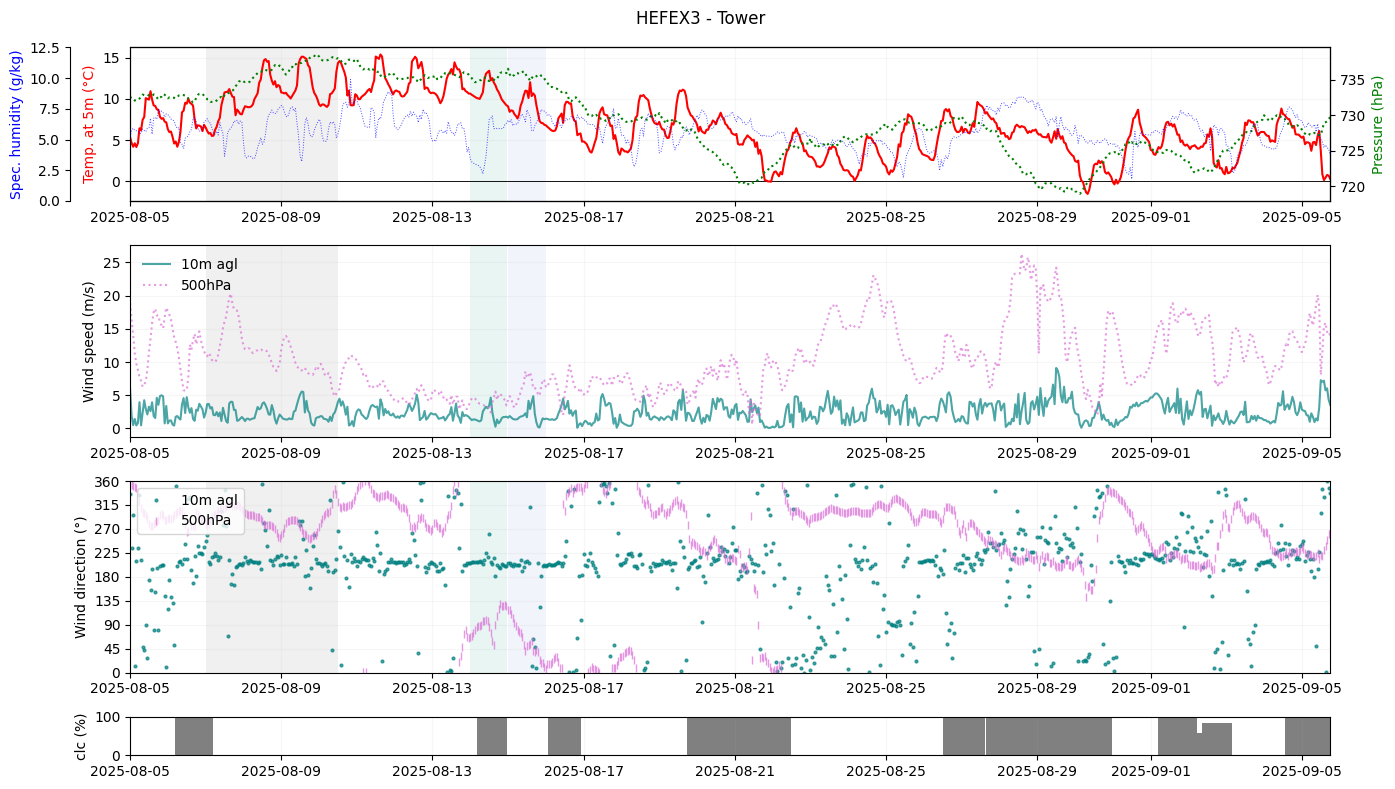

In [12]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(14,8),gridspec_kw={'height_ratios': [1, 1.25, 1.25, .25]})

# temp
ax = axs[0]
ax.plot(t_ml, ds_l5['temp'].values[:, -1, cell_idx] - 273.15, c='red', label='Temp. (5m)')
ax.axhline(0,c='black',zorder=-1, lw=.7)
ax.set_ylabel('Temp. at 5m (°C)', color='red')

# pres
axr = ax.twinx()
axr.plot(t_ml, pres, c='green', ls=':', label='Surface Pressure')
axr.set_ylabel('Pressure (hPa)', color='green')

# qv
ax2 = ax.twinx()         
ax2.spines['left'].set_position(('axes', -0.05))
ax2.yaxis.set_label_position('left')
ax2.yaxis.tick_left()
ax2.plot(t_ml, ds_l5['qv'].values[:, -1, cell_idx]*1000, c='blue', label='qv (5m)', lw=.7, alpha=.7, ls=':')
ax2.set_ylabel("Spec. humidity (g/kg)", color='blue')
ax2.set_ylim(0,12.5)

# wind speed
ax = axs[1]
ax.plot(t_ml, wspd_sfc, label='10m agl', alpha=.7, c='teal')
ax.plot(t_pl, wspd_500, label='500hPa', alpha=.7, c='orchid', ls=':')
ax.set_ylabel('Wind speed (m/s)')
ax.legend(loc='upper left', frameon=False)

# wind direction
ax = axs[2]
ax.plot(t_ml, wdir_sfc, label='10m agl', ls='none', marker='.', ms=4, alpha=.7, c='teal')
ax.plot(t_pl, wdir_500, label='500hPa', ls='none', marker='|', alpha=.7, c='orchid')
ax.set_ylabel('Wind direction (°)')
ax.set_ylim(0, 360)
ax.set_yticks(range(0, 361, 45), range(0, 361, 45))
ax.legend(loc='upper left')

# cloud cover
ax = axs[3]
ax.bar(t_pl, cc, color='grey')
ax.set_ylabel('clc (%)')
ax.set_ylim(0,100)

for i,ax in enumerate(axs):
    ax.grid(alpha=.1)
    ax.set_xlim(dt_from, dt_to)

    if i > 2: continue
    for j,s in enumerate(shading):
        ax.axvspan(s[0], s[1], facecolor=shading_c[j], zorder=-10, alpha=.3)

#plt.suptitle(f'{n.upper()} - Tower')
plt.tight_layout()
#plt.savefig(f'{n.upper()}_meteo_conditions_{obs_name}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()